<a href="https://colab.research.google.com/github/Hassaan-347/DAV-Assignment-1/blob/main/Assignment1_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAV Assignment 1
## Performed by:
### Name: Hassaan Shakeel Shaikh
### UIN: 242A007
### Roll No.: 61

How to load the dataset:

1. The given CSV file in the repository needs to be downloaded.
2. In Google Colab, Open Files (represented as a folder)
3. Click on "Upload to session storage" (represented as an upward pointing arrow) and select the CSV dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Quote-Equity-FORTIS-EQ-13-03-2025-13-03-2026.csv")

# Preview
print(df.head())
print(df.info())

          DATE SERIES    OPEN    HIGH     LOW PREV. CLOSE     LTP   CLOSE  \
0  13-Mar-2026     EQ  859.00  863.60  837.95      859.50  840.00  839.75   
1  12-Mar-2026     EQ  874.00  875.05  852.00      881.20  864.00  859.50   
2  11-Mar-2026     EQ  884.00  887.75  873.60      881.80  880.00  881.20   
3  10-Mar-2026     EQ  885.00  890.00  878.20      878.45  885.00  881.80   
4  09-Mar-2026     EQ  869.50  899.80  856.20      892.55  879.75  878.45   

     VWAP     52W H  52W L   VOLUME              VALUE  NO. OF  TRADES  
0  846.35  1,104.30  595.6  1002669    84,86,04,140.60           33790  
1  860.08  1,104.30  595.6  2366155  2,03,50,75,998.00           59160  
2  880.60  1,104.30  595.6  1346013  1,18,53,02,870.65           73257  
3  882.90  1,104.30  595.6   867711    76,61,01,784.00           34750  
4  871.72  1,104.30  595.6  1416619  1,23,48,95,386.70           42031  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 14 colu

# 1. Data Preprocessing

In [3]:
# (a) Convert the date column to a proper datetime format.
df["DATE"] = pd.to_datetime(df["DATE"], format="%d-%b-%Y")
print(df.head())
print(df.info())

        DATE SERIES    OPEN    HIGH     LOW PREV. CLOSE     LTP   CLOSE  \
0 2026-03-13     EQ  859.00  863.60  837.95      859.50  840.00  839.75   
1 2026-03-12     EQ  874.00  875.05  852.00      881.20  864.00  859.50   
2 2026-03-11     EQ  884.00  887.75  873.60      881.80  880.00  881.20   
3 2026-03-10     EQ  885.00  890.00  878.20      878.45  885.00  881.80   
4 2026-03-09     EQ  869.50  899.80  856.20      892.55  879.75  878.45   

     VWAP     52W H  52W L   VOLUME              VALUE  NO. OF  TRADES  
0  846.35  1,104.30  595.6  1002669    84,86,04,140.60           33790  
1  860.08  1,104.30  595.6  2366155  2,03,50,75,998.00           59160  
2  880.60  1,104.30  595.6  1346013  1,18,53,02,870.65           73257  
3  882.90  1,104.30  595.6   867711    76,61,01,784.00           34750  
4  871.72  1,104.30  595.6  1416619  1,23,48,95,386.70           42031  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 14 columns):
 #   C

In [4]:
# (b) Handle any missing values, if present.
print(df.isnull().sum())

DATE              0
SERIES            0
OPEN              0
HIGH              0
LOW               0
PREV. CLOSE       0
LTP               0
CLOSE             0
VWAP              0
52W H             0
52W L             0
VOLUME            0
VALUE             0
NO. OF  TRADES    0
dtype: int64


The above shows that there are no missing values in the dataset.

We do not need to handle the data in that regard.

In [5]:
# Remove commas from selected columns and convert to numeric
cols_to_clean = ["OPEN", "HIGH", "LOW", "PREV. CLOSE", "LTP", "CLOSE", "VWAP",
                 "52W H", "52W L", "VOLUME", "VALUE", "NO. OF  TRADES"]

for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ""), errors="coerce")

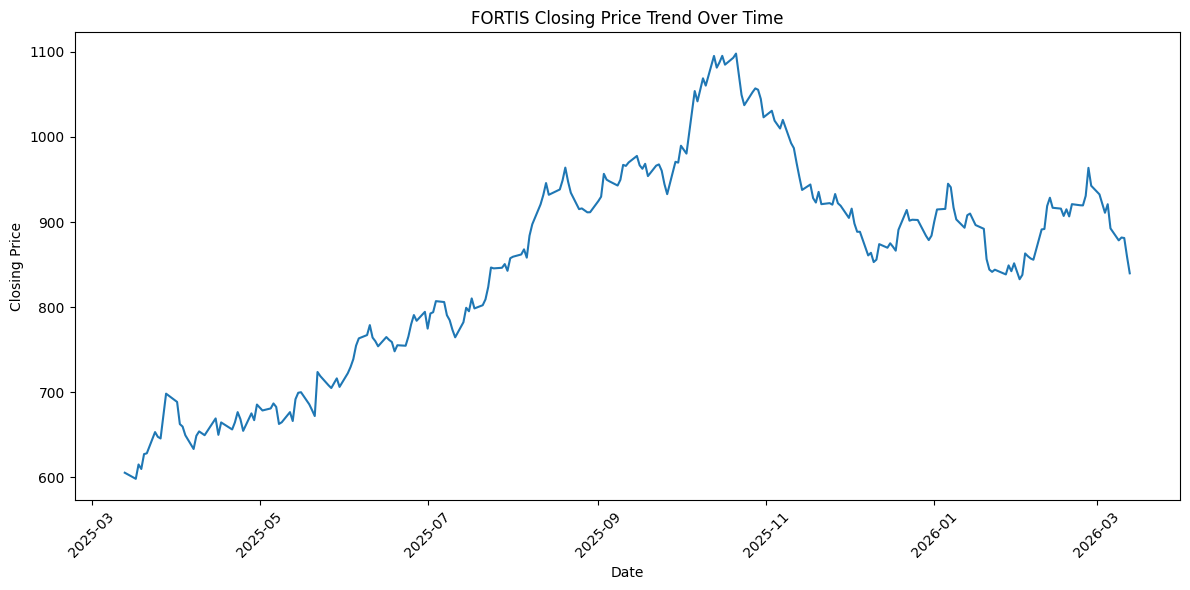

In [6]:
# (c) Visualize the closing price trend over time.
df = df.sort_values("DATE")
plt.figure(figsize=(12, 6))
plt.plot(df["DATE"], df["CLOSE"])
plt.title("FORTIS Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. ARIMA Model Implementation

In [7]:
import numpy as np

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [8]:
df = df.sort_values("DATE")
df = df.dropna(subset=["CLOSE"])

ts = df.set_index("DATE")["CLOSE"]
print(ts.head())

DATE
2025-03-13    605.45
2025-03-17    598.30
2025-03-18    615.15
2025-03-19    609.85
2025-03-20    627.35
Name: CLOSE, dtype: float64


In [9]:
# (a) Conduct an ADF test for stationariety
adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -2.0508411695134328
p-value: 0.2647351508902352
Critical Values:
   1%: -3.457105309726321
   5%: -2.873313676101283
   10%: -2.5730443824681606


If p-value < 0.05, we consider the series as stationary

If p-value is >= 0.05, we consider the series as non-stationary

In [10]:
# Differencing the series
ts_diff = ts.diff().dropna()

# Running ADF again
adf_result_diff = adfuller(ts_diff)

print("ADF Statistic after differencing:", adf_result_diff[0])
print("p-value after differencing:", adf_result_diff[1])
print("Critical Values:")
for key, value in adf_result_diff[4].items():
    print(f"   {key}: {value}")

ADF Statistic after differencing: -10.098023231983591
p-value after differencing: 1.0778671429821184e-17
Critical Values:
   1%: -3.4573260719088132
   5%: -2.873410402808354
   10%: -2.573095980841316


<Figure size 1000x400 with 0 Axes>

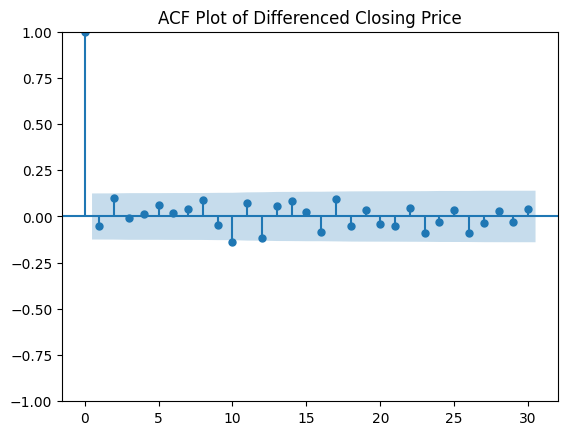

<Figure size 1000x400 with 0 Axes>

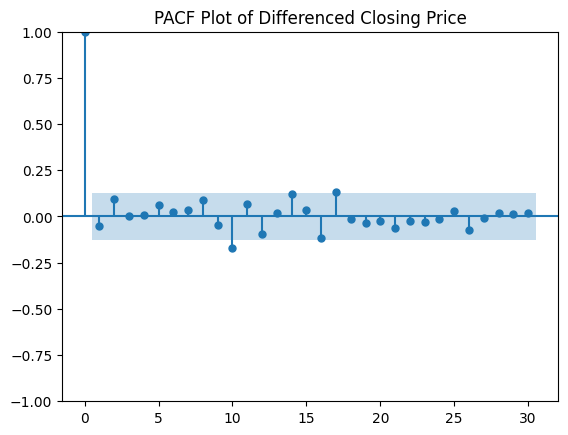

In [11]:
# (b) Use ACF and PACF plots to determine the optimal ARIMA parameters (p, d, q)
plt.figure(figsize=(10, 4))
plot_acf(ts_diff, lags=30)
plt.title("ACF Plot of Differenced Closing Price")
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(ts_diff, lags=30, method="ywm")
plt.title("PACF Plot of Differenced Closing Price")
plt.show()

In [12]:
# (c) Fit an ARIMA model to the time series and evaluate its performance
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

print("Training data size:", len(train))
print("Testing data size:", len(test))

Training data size: 198
Testing data size: 50


In [13]:
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  198
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -806.477
Date:                Mon, 16 Mar 2026   AIC                           1618.955
Time:                        11:36:11   BIC                           1628.804
Sample:                             0   HQIC                          1622.942
                                - 198                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5016      0.496     -1.011      0.312      -1.474       0.471
ma.L1          0.4031      0.527      0.764      0.445      -0.631       1.437
sigma2       210.6930     14.952     14.091      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [14]:
forecast = model_fit.forecast(steps=len(test))

forecast.index = test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [15]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 31.267744435546756
RMSE: 35.19528655208193


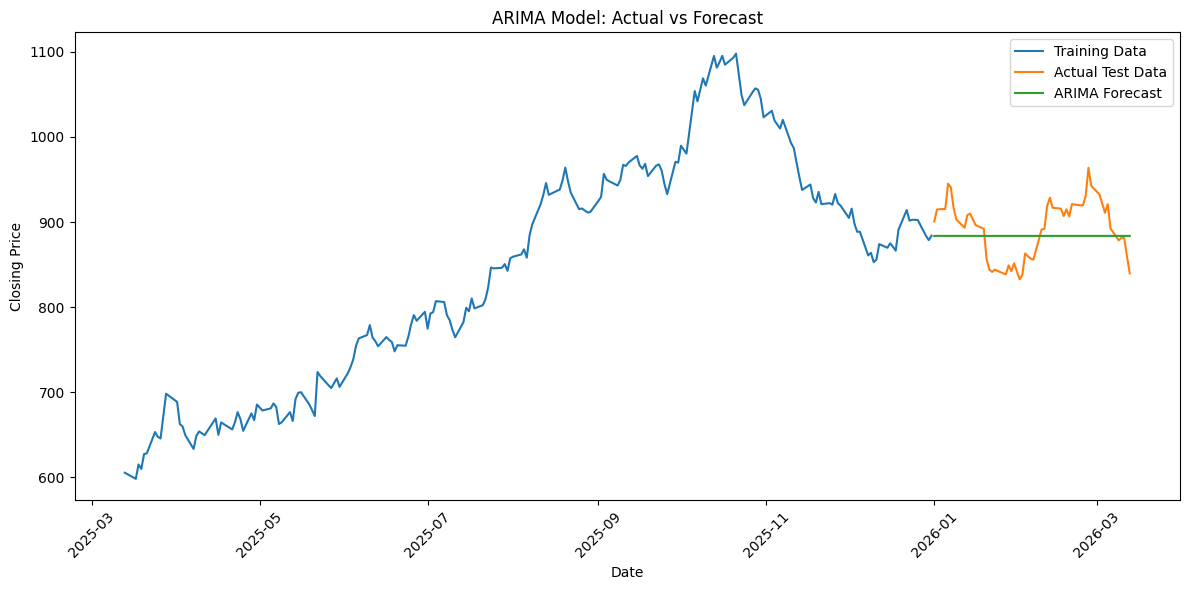

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(forecast.index, forecast, label="ARIMA Forecast")
plt.title("ARIMA Model: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Future Price Prediction

In [17]:
# (a) Use the trained ARIMA model to forecast the next 30 days' closing prices.
future_steps = 30
future_forecast = model_fit.forecast(steps=future_steps)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [18]:
# Create future business-day index
last_date = ts.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=future_steps)

future_forecast.index = future_dates

# Print forecasted values
print("Next 30 Days Forecast:")
print(future_forecast)

Next 30 Days Forecast:
2026-03-16    883.563271
2026-03-17    883.782333
2026-03-18    883.672452
2026-03-19    883.727568
2026-03-20    883.699922
2026-03-23    883.713789
2026-03-24    883.706833
2026-03-25    883.710322
2026-03-26    883.708572
2026-03-27    883.709450
2026-03-30    883.709010
2026-03-31    883.709231
2026-04-01    883.709120
2026-04-02    883.709175
2026-04-03    883.709148
2026-04-06    883.709162
2026-04-07    883.709155
2026-04-08    883.709158
2026-04-09    883.709156
2026-04-10    883.709157
2026-04-13    883.709157
2026-04-14    883.709157
2026-04-15    883.709157
2026-04-16    883.709157
2026-04-17    883.709157
2026-04-20    883.709157
2026-04-21    883.709157
2026-04-22    883.709157
2026-04-23    883.709157
2026-04-24    883.709157
Freq: B, Name: predicted_mean, dtype: float64


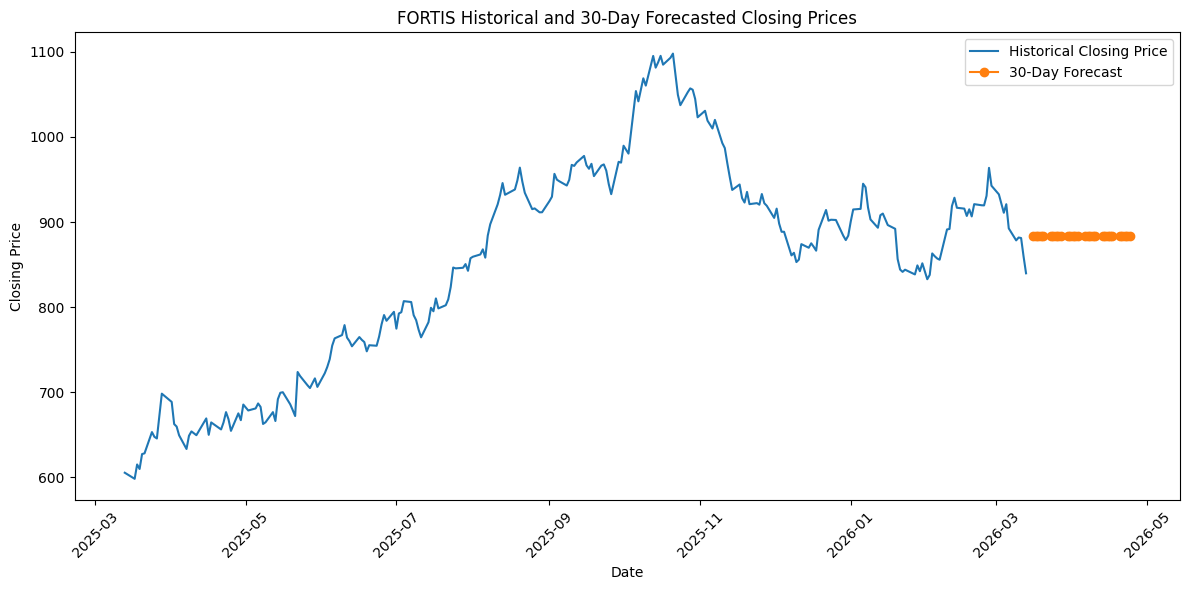

In [19]:
# (b) Visualize the forecasted prices alongside historical data.
plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts, label="Historical Closing Price")
plt.plot(future_forecast.index, future_forecast, marker="o", label="30-Day Forecast")

plt.title("FORTIS Historical and 30-Day Forecasted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
forecast_df = pd.DataFrame({
    "Date": future_forecast.index,
    "Forecasted_Close": future_forecast.values
})

print(forecast_df)

         Date  Forecasted_Close
0  2026-03-16        883.563271
1  2026-03-17        883.782333
2  2026-03-18        883.672452
3  2026-03-19        883.727568
4  2026-03-20        883.699922
5  2026-03-23        883.713789
6  2026-03-24        883.706833
7  2026-03-25        883.710322
8  2026-03-26        883.708572
9  2026-03-27        883.709450
10 2026-03-30        883.709010
11 2026-03-31        883.709231
12 2026-04-01        883.709120
13 2026-04-02        883.709175
14 2026-04-03        883.709148
15 2026-04-06        883.709162
16 2026-04-07        883.709155
17 2026-04-08        883.709158
18 2026-04-09        883.709156
19 2026-04-10        883.709157
20 2026-04-13        883.709157
21 2026-04-14        883.709157
22 2026-04-15        883.709157
23 2026-04-16        883.709157
24 2026-04-17        883.709157
25 2026-04-20        883.709157
26 2026-04-21        883.709157
27 2026-04-22        883.709157
28 2026-04-23        883.709157
29 2026-04-24        883.709157


# 4. Interpretation

Observing the graphs above, we see an upward trend from March to October 2025, after which we notice a downward trend from November 2025 to January 2026.

So far, we observe a form of stability moving onward from January 2026, with fluctuations holding a near constant mean. We can expect stability.

The ARIMA model suggests a stable trend in the stock’s closing price over the next 30 trading days. This conclusion is based on the direction of the forecasted values in the prediction plot. However, because stock prices are influenced by many external factors, the forecast should be considered an estimate rather than an exact future outcome.